Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series,
and decompose it into trend, seasonality, and residual components

First 5 rows of the dataset:
     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121

Files saved: original_air_passengers.png, decomposed_air_passengers.png, processed_air_passengers.csv


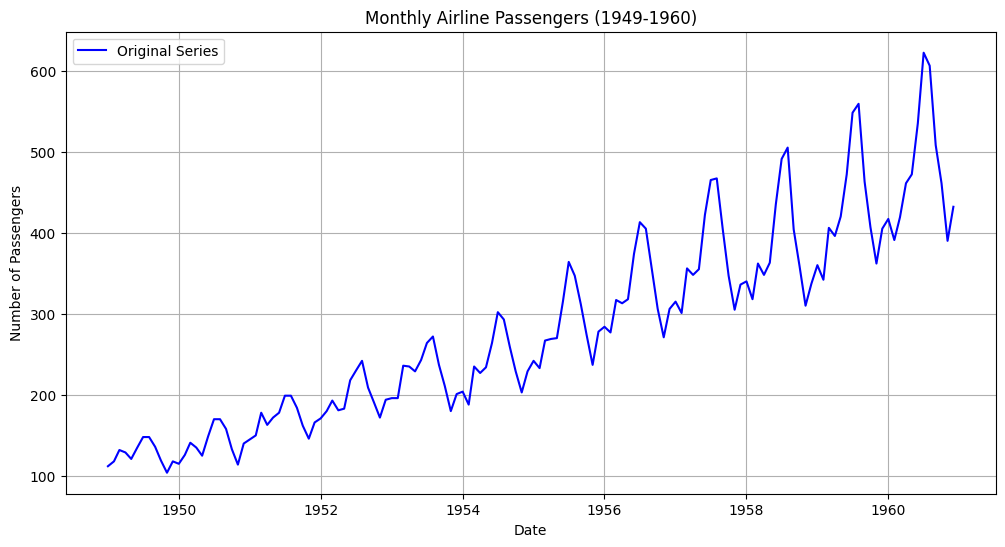

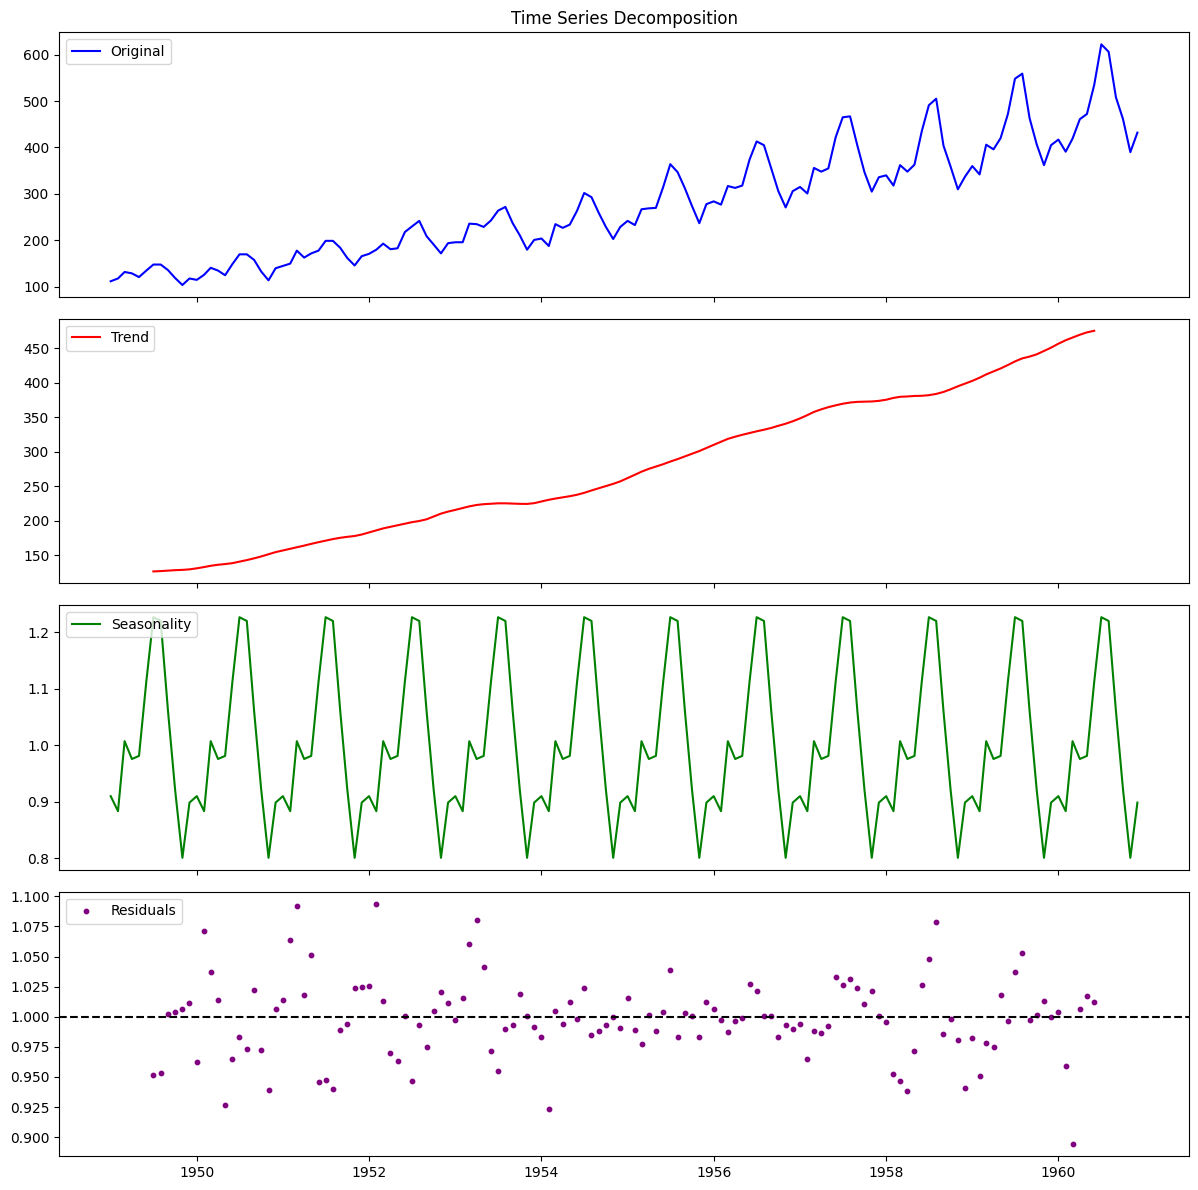

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

# Load the AirPassengers dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

# Print first few rows to check column names
print("First 5 rows of the dataset:")
print(df.head())

# The columns are typically 'Month' and 'Passengers'
# Rename columns if necessary for consistency
df.columns = ['Month', 'Passengers']

# Convert 'Month' to datetime and set as index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# 1. Plot the original time series
plt.figure(figsize=(12, 6))
plt.plot(df['Passengers'], label='Original Series', color='blue')
plt.title('Monthly Airline Passengers (1949-1960)')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.savefig('original_air_passengers.png')
# plt.close() # Keep figure for later if needed, but savefig works best with close for memory

# 2. Decompose the time series
# We use a multiplicative model because the amplitude of the seasonal variation increases over time
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

# Extract components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# 3. Plot the decomposed components
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# Original
axes[0].plot(df['Passengers'], label='Original', color='blue')
axes[0].set_title('Time Series Decomposition')
axes[0].legend(loc='upper left')

# Trend
axes[1].plot(trend, label='Trend', color='red')
axes[1].legend(loc='upper left')

# Seasonality
axes[2].plot(seasonal, label='Seasonality', color='green')
axes[2].legend(loc='upper left')

# Residuals
axes[3].scatter(df.index, residual, label='Residuals', color='purple', s=10)
axes[3].axhline(y=1, color='black', linestyle='--') # Multiplicative residual mean is 1
axes[3].legend(loc='upper left')

plt.tight_layout()
plt.savefig('decomposed_air_passengers.png')

# Output data to CSV for the user
df.to_csv('processed_air_passengers.csv')
print("\nFiles saved: original_air_passengers.png, decomposed_air_passengers.png, processed_air_passengers.csv")

Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
detect anomalies. Visualize the anomalies on a 2D scatter plot.

Anomalies detected and plot saved.
is_anomaly
Normal     499
Anomaly     21
Name: count, dtype: int64


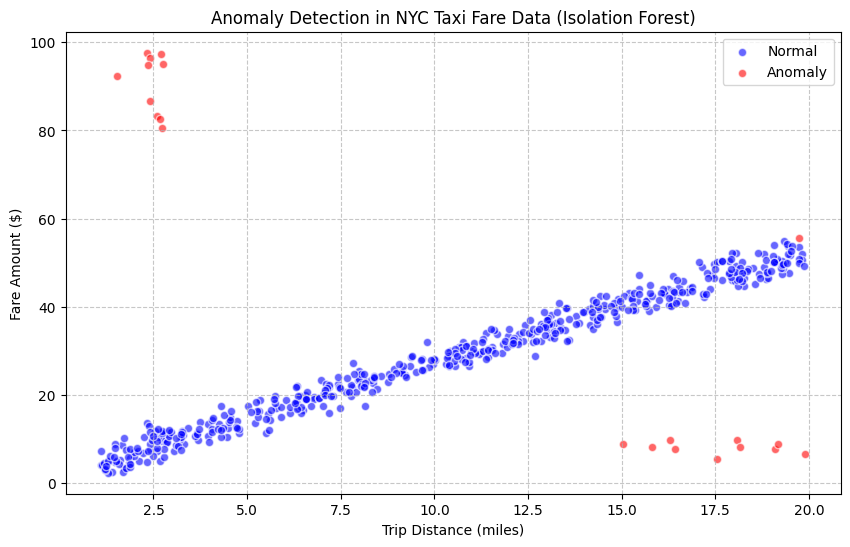

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Generating a synthetic subset that mimics NYC Taxi Fare data characteristics
# Columns: trip_distance (miles) and fare_amount ($)
np.random.seed(42)

# Normal data: roughly linear relationship between distance and fare
n_samples = 500
distance = np.random.uniform(1, 20, n_samples)
fare = 2.5 + 2.5 * distance + np.random.normal(0, 2, n_samples)

# Add some anomalies
# 1. High fare, low distance (e.g., a "scam" or error)
anom_dist_1 = np.random.uniform(1, 3, 10)
anom_fare_1 = np.random.uniform(80, 100, 10)

# 2. Low fare, high distance (e.g., a "flat rate" mistake or data entry error)
anom_dist_2 = np.random.uniform(15, 20, 10)
anom_fare_2 = np.random.uniform(5, 10, 10)

# Combine into a DataFrame
df = pd.DataFrame({
    'trip_distance': np.concatenate([distance, anom_dist_1, anom_dist_2]),
    'fare_amount': np.concatenate([fare, anom_fare_1, anom_fare_2])
})

# Apply Isolation Forest
# contamination is the expected proportion of outliers (approx 4% here)
iso_forest = IsolationForest(n_estimators=100, contamination=0.04, random_state=42)
df['anomaly_score'] = iso_forest.fit_predict(df[['trip_distance', 'fare_amount']])

# -1 indicates an anomaly, 1 indicates normal data
df['is_anomaly'] = df['anomaly_score'].map({1: 'Normal', -1: 'Anomaly'})

# Visualization
plt.figure(figsize=(10, 6))
colors = {'Normal': 'blue', 'Anomaly': 'red'}

for label, color in colors.items():
    subset = df[df['is_anomaly'] == label]
    plt.scatter(subset['trip_distance'], subset['fare_amount'],
                c=color, label=label, alpha=0.6, edgecolors='w')

plt.title('Anomaly Detection in NYC Taxi Fare Data (Isolation Forest)')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('nyc_taxi_anomalies.png')

print("Anomalies detected and plot saved.")
print(df['is_anomaly'].value_counts())

Question 8: Train a SARIMA model on the monthly airline passengers dataset.
Forecast the next 12 months and visualize the results.


Forecast for 1961:
              Forecast
1961-01-01  447.222620
1961-02-01  422.734098
1961-03-01  457.700895
1961-04-01  492.277505
1961-05-01  505.563365
1961-06-01  565.671782
1961-07-01  651.986404
1961-08-01  639.634242
1961-09-01  543.058845
1961-10-01  493.727025
1961-11-01  426.938001
1961-12-01  470.135608


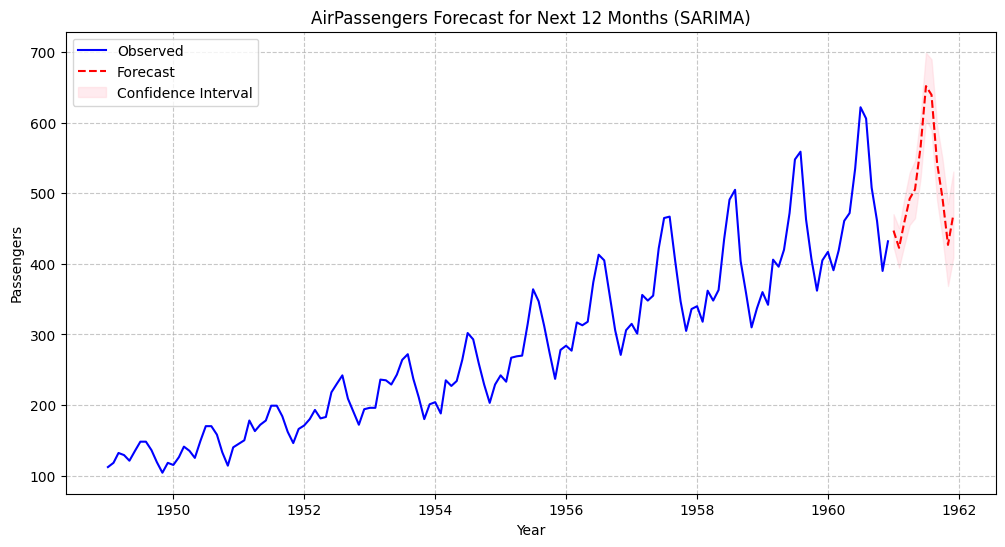

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Re-create the AirPassengers dataset (as established in previous steps)
passengers = [
    112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118,
    115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140,
    145, 150, 178, 163, 172, 178, 199, 199, 184, 162, 146, 166,
    171, 180, 193, 181, 183, 218, 230, 242, 209, 191, 172, 194,
    196, 196, 236, 235, 229, 243, 264, 272, 237, 211, 180, 201,
    204, 188, 235, 227, 234, 264, 302, 293, 259, 229, 203, 229,
    242, 233, 267, 269, 270, 315, 364, 347, 312, 274, 237, 278,
    284, 277, 317, 313, 318, 374, 413, 405, 355, 306, 271, 306,
    315, 301, 356, 348, 355, 422, 465, 467, 404, 347, 305, 336,
    340, 318, 362, 348, 363, 435, 491, 505, 404, 359, 310, 337,
    360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405,
    417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432
]
dates = pd.date_range(start='1949-01-01', periods=len(passengers), freq='MS')
df = pd.DataFrame({'Passengers': passengers}, index=dates)

# 2. Train the SARIMA model
# Order (p, d, q) and Seasonal Order (P, D, Q, s)
# (1, 1, 1) x (1, 1, 1, 12) is a common starting point for this dataset
model = SARIMAX(df['Passengers'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)
model_fit = model.fit(disp=False)

# 3. Forecast the next 12 months
forecast_steps = 12
forecast_res = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_res.summary_frame()['mean']
confidence_intervals = forecast_res.conf_int()

# Create index for the forecast
forecast_index = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1),
                               periods=forecast_steps, freq='MS')

# 4. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df['Passengers'], label='Observed', color='blue')
plt.plot(forecast_index, forecast_mean, label='Forecast', color='red', linestyle='--')
plt.fill_between(forecast_index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1],
                 color='pink', alpha=0.3, label='Confidence Interval')

plt.title('AirPassengers Forecast for Next 12 Months (SARIMA)')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('sarima_forecast.png')

print("Forecast for 1961:")
print(pd.DataFrame({'Forecast': forecast_mean.values}, index=forecast_index))

Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect
anomalies and visualize them using matplotlib.


Total points: 220
Detected anomalies: 22


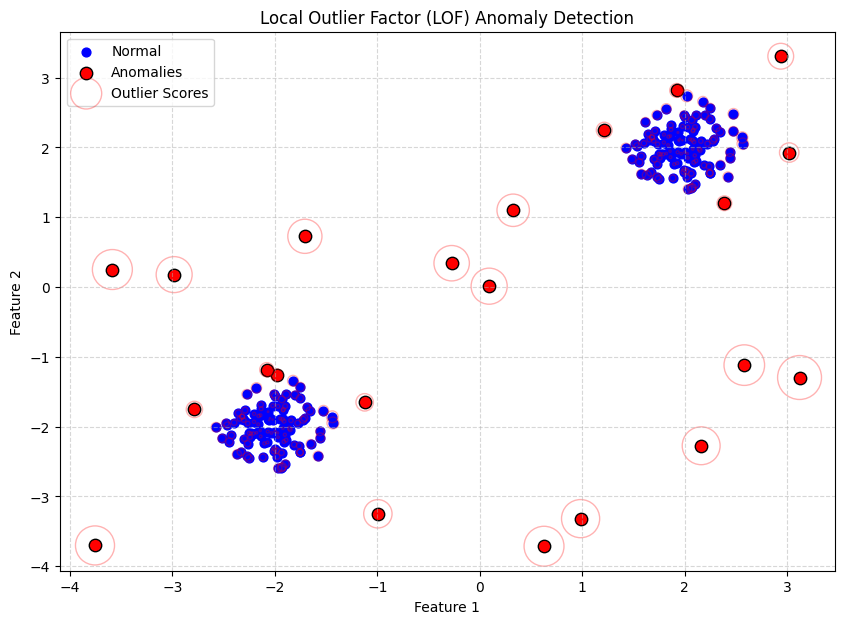

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# 1. Create a synthetic numerical dataset (simulating taxi or financial data)
# Most points are in a dense cluster; anomalies are isolated or in low-density areas.
np.random.seed(42)

# Generate normal data (two clusters)
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Generate some outliers
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X_inliers, X_outliers]

# 2. Apply Local Outlier Factor (LOF)
# n_neighbors=20 is standard; novelty=False because we are doing outlier detection on the train set
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X)
# Negative outlier factor: higher values indicate more 'anomalous' behavior
X_scores = lof.negative_outlier_factor_

# 3. Visualize the results
plt.figure(figsize=(10, 7))

# Plot normal points
plt.scatter(X[y_pred == 1, 0], X[y_pred == 1, 1], color='blue', s=40, label='Normal')

# Plot outliers
plt.scatter(X[y_pred == -1, 0], X[y_pred == -1, 1], color='red', s=80, edgecolors='k', label='Anomalies')

# Draw circles around points proportional to their outlier scores
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())
plt.scatter(X[:, 0], X[:, 1], s=1000 * radius, edgecolors='r', facecolors='none', label='Outlier Scores', alpha=0.3)

plt.title('Local Outlier Factor (LOF) Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('lof_anomalies.png')

print(f"Total points: {len(X)}")
print(f"Detected anomalies: {np.sum(y_pred == -1)}")